In [31]:
# Librerie di base
import numpy as np
import pandas as pd

# Visualizzazione
import seaborn as sns
import matplotlib.pyplot as plt

# Modelli e metriche
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve, auc, ConfusionMatrixDisplay)
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import MinMaxScaler

from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

from sklearn.model_selection import StratifiedKFold


from imblearn.under_sampling import TomekLinks
from collections import Counter

from imblearn.over_sampling import ADASYN

from itertools import combinations
from scipy.stats import randint
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from imblearn.under_sampling import TomekLinks
from sklearn.model_selection import StratifiedKFold
from imblearn.under_sampling import TomekLinks, EditedNearestNeighbours, CondensedNearestNeighbour

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import os

# import cnn


In [32]:
train = pd.read_csv('../01_Outlier_detection/train_cleaned_outliers.csv')
test = pd.read_csv('../test_set/test.csv')

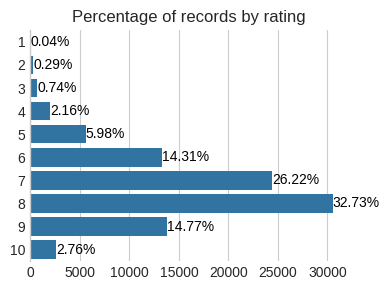

In [33]:
ds = train

plt.figure(figsize=(4, 3))
plt.style.use('seaborn-v0_8-whitegrid')

ax = sns.countplot(data=ds, y="rating", legend=False)
plt.ylabel("")
plt.xlabel("")
plt.title("Percentage of records by rating")
total = len(ds)
for bar in ax.patches:
    width = bar.get_width() 
    percentage = f"{(width / total) * 100:.2f}%"
    ax.text(width + 1, bar.get_y() + bar.get_height()/2, percentage, 
            va='center', fontsize=10, color='black')

sns.despine(ax=ax, top=True, right=True, bottom=True)

plt.tight_layout()
plt.show()
plt.close()

In [34]:
train['isLow'] = (train['rating'] <= 4).astype(int)
test['isLow'] = (test['rating'] <= 4).astype(int)

train['is10'] = (train['rating'] > 9).astype(int)
test['is10'] = (test['rating'] > 9).astype(int)

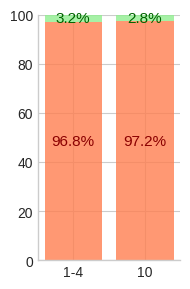

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcola le percentuali
def get_percentages(df, col):
    total = len(df)
    percentages = {}
    for value in sorted(df[col].unique()):
        count = len(df[df[col] == value])
        percentage = (count / total) * 100
        percentages[value] = percentage
    return percentages

# Ottieni le percentuali per entrambe le colonne
lowseries_perc = get_percentages(train, 'isLow')
ten_perc = get_percentages(train, 'is10')

# Crea il plot con barre stackate
fig, ax = plt.subplots(figsize=(2, 3))
plt.style.use('seaborn-v0_8-whitegrid')

# Dati per il plot
categories = ['1-4', '10']
not_class = [lowseries_perc[0], ten_perc[0]]  # Classe 0 (non è la classe)
is_class = [lowseries_perc[1], ten_perc[1]]   # Classe 1 (è la classe)

x = range(len(categories))

# Crea barre stackate
bars1 = ax.bar(x, not_class, label='Not Class (0)', color='coral', alpha=0.8)
bars2 = ax.bar(x, is_class, bottom=not_class, label='Is Class (1)', color='lightgreen', alpha=0.8)

# Aggiungi percentuali al centro di ogni sezione
for i, (bar1, bar2, perc0, perc1) in enumerate(zip(bars1, bars2, not_class, is_class)):
    # Testo per la parte inferiore (classe 0)
    ax.text(bar1.get_x() + bar1.get_width()/2., perc0/2,
            f'{perc0:.1f}%', ha='center', va='center', color='darkred', fontsize=11)
    
    # Testo per la parte superiore (classe 1)
    ax.text(bar2.get_x() + bar2.get_width()/2., perc0 + perc1/2,
            f'{perc1:.1f}%', ha='center', va='center', color='darkgreen', fontsize=11)

# Personalizza il plot
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylim(0, 100)

# Rimuovi spines
sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()
plt.show()
plt.close()


In [36]:
X_low_train = train.drop(columns=['rating', 'averageRating', 'originalTitle', 'isLow', 'is10'])
y_low_train = train['isLow']

X_low_test = test.drop(columns=['rating', 'averageRating', 'originalTitle', 'isLow', 'is10'])
y_low_test = test['isLow']


X_10_train = train.drop(columns=['rating', 'averageRating', 'originalTitle', 'isLow', 'is10'])
y_10_train = train['is10']

X_10_test = test.drop(columns=['rating', 'averageRating', 'originalTitle', 'isLow', 'is10'])
y_10_test = test['is10']

In [37]:
minmax_scaler = MinMaxScaler()
X_low_train_scaled = minmax_scaler.fit_transform(X_low_train)
X_low_test_scaled = minmax_scaler.transform(X_low_test)
X_10_train_scaled = minmax_scaler.fit_transform(X_10_train)
X_10_test_scaled = minmax_scaler.transform(X_10_test)


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score, roc_auc_score
)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks, EditedNearestNeighbours
from imblearn.combine import SMOTEENN
import warnings
import os
# import make_scorer from sklearn.metrics
from sklearn.metrics import make_scorer
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.tree import DecisionTreeClassifier

def resample_data(strategy, X_train, y_train):
    """Applica la strategia di bilanciamento al dataset."""
    if strategy is None:
        return X_train.copy(), y_train.copy()
    try:
        X_resampled, y_resampled = strategy.fit_resample(X_train, y_train)
        return X_resampled, y_resampled
    except Exception as e:
        print(f"Error in resampling: {e}")
        return None, None

def train_model(X_train, y_train, X_test):
    """Allena il modello Decision Tree con i parametri migliori."""
    try:

        # Esegui HalvingGridSearchCV per trovare i migliori parametri
        param_grid = {
            'criterion': ['gini', 'entropy'],
            'max_depth': [5, 10, 15, 20, 25, 30],
            'min_samples_split': [2, 5, 10, 15, 20],
            'min_samples_leaf': [1, 3, 5, 10, 15],
            'max_features': ['log2', 0.5, 0.7],
            'class_weight': [None, 'balanced']
        }
        
        custom_f1_scorer = make_scorer(f1_score, average='binary', zero_division=0)
        print("Starting HalvingGridSearchCV...")
        halving_search = HalvingGridSearchCV(
            estimator=DecisionTreeClassifier(random_state=42),
            param_grid=param_grid,
            factor=1.6,
            cv=StratifiedKFold(n_splits=8, shuffle=True, random_state=42),
            scoring=custom_f1_scorer,
            n_jobs=-1,
            random_state=42,
            error_score=np.nan
        )
        halving_search.fit(X_train, y_train)
        model = halving_search.best_estimator_
        
        # Effettua le predizioni
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
        return model, y_pred, y_proba
    except Exception as e:
        print(f"Error in model training: {e}")
        return None, None, None

def calculate_metrics(y_test, y_pred, y_proba):
    """Calcola le metriche di valutazione."""
    try:
        return {
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall': recall_score(y_test, y_pred, zero_division=0),
            'f1_score': f1_score(y_test, y_pred, zero_division=0),
            'roc_auc': roc_auc_score(y_test, y_proba)
        }
    except Exception as e:
        print(f"Error in metrics calculation: {e}")
        return {'precision': 0, 'recall': 0, 'f1_score': 0, 'roc_auc': 0}

def run_experiment(X_train, y_train, X_test, y_test, strategies):
    """Esegue esperimenti con diverse strategie di bilanciamento."""
    results = []
    models = {}  # Dizionario per salvare i modelli allenati
    y_probas = {}  # Dizionario per salvare le probabilità predette

    for strategy_name, strategy in strategies.items():
        print(f"Strategy: {strategy_name}")
        
        # Numero di righe prima del resampling
        original_rows = len(X_train)
        
        X_resampled, y_resampled = resample_data(strategy, X_train, y_train)
        if X_resampled is None:
            continue
        
        # Numero di righe dopo il resampling
        resampled_rows = len(X_resampled)
        
        model, y_pred, y_proba = train_model(X_resampled, y_resampled, X_test)
        if model is None:
            continue
        
        metrics = calculate_metrics(y_test, y_pred, y_proba)
        
        # Aggiungi il numero di righe prima e dopo il resampling alle metriche
        metrics['original_rows'] = original_rows
        metrics['resampled_rows'] = resampled_rows
        
        results.append({'strategy': strategy_name, **metrics})
        models[strategy_name] = model  # Salva il modello
        y_probas[strategy_name] = y_proba  # Salva le probabilità predette

    return pd.DataFrame(results), models, y_probas

# Configurazione delle strategie di bilanciamento
strategies_config = {
    # BASELINE
    'Baseline': None,
    
    # SMOTE Variants (k_neighbors fine-tuning) - SMOTE non supporta n_jobs
    'SMOTE(3)': SMOTE(random_state=42, k_neighbors=3),
    'SMOTE(5)': SMOTE(random_state=42, k_neighbors=5),
    'SMOTE(7)': SMOTE(random_state=42, k_neighbors=7),

    'ENN(3)': EditedNearestNeighbours(n_neighbors=3, n_jobs=-1),
    'ENN(5)': EditedNearestNeighbours(n_neighbors=5, n_jobs=-1),
    'ENN(7)': EditedNearestNeighbours(n_neighbors=7, n_jobs=-1),
        
    # SMOTEENN with both SMOTE and ENN fine-tuned - Solo ENN supporta n_jobs
    'SMOTEENN(3,3)': SMOTEENN(random_state=42, smote=SMOTE(random_state=42, k_neighbors=3), enn=EditedNearestNeighbours(n_neighbors=3, n_jobs=-1)),
    'SMOTEENN(5,5)': SMOTEENN(random_state=42, smote=SMOTE(random_state=42, k_neighbors=5), enn=EditedNearestNeighbours(n_neighbors=5, n_jobs=-1)),
    'SMOTEENN(3,5)': SMOTEENN(random_state=42, smote=SMOTE(random_state=42, k_neighbors=3), enn=EditedNearestNeighbours(n_neighbors=5, n_jobs=-1)),
    'SMOTEENN(5,3)': SMOTEENN(random_state=42, smote=SMOTE(random_state=42, k_neighbors=5), enn=EditedNearestNeighbours(n_neighbors=3, n_jobs=-1)),
}

In [39]:
# low_results, low_models, low_probas = run_experiment(X_low_train, y_low_train, X_low_test, y_low_test, strategies= strategies_config)

In [40]:
# import joblib
# import json

# created_results_dir = 'results/model'
# created_proba_dir = 'results/proba'
# # Crea la cartella se non esiste
# if not os.path.exists(created_results_dir):
#     os.makedirs(created_results_dir)
# if not os.path.exists(created_proba_dir):
#     os.makedirs(created_proba_dir)

# # to json low_results, low_models, low_probas
# low_results.to_json('results/low_results.json', orient='records', indent=4)
# # Salva i modelli in formato pickle
# for strategy, model in low_models.items():
#     joblib.dump(model, f'results/model/low_model_{strategy}.pkl')
# # Salva le probabilità in formato pickle
# for strategy, proba in low_probas.items():
#     with open(f'results/proba/low_proba_{strategy}.pkl', 'wb') as f:
#         joblib.dump(proba, f)

In [41]:
# # load low_results, low_models, low_probas
low_results = pd.read_json('results/low_results.json', orient='records')
low_models = {}
for strategy in low_results['strategy'].unique():
    low_models[strategy] = joblib.load(f'results/model/low_model_{strategy}.pkl')
low_probas = {}
for strategy in low_results['strategy'].unique():
    with open(f'results/proba/low_proba_{strategy}.pkl', 'rb') as f:
        low_probas[strategy] = joblib.load(f)


In [42]:
def plot_results_with_roc(results, output_dir, class_name, y_test, y_probas):
    """Crea visualizzazioni per i risultati con stile minimalista e moderno."""
    os.makedirs(output_dir, exist_ok=True)
    
    # Stile minimalista
    plt.style.use('default')
    
    # Calcola la variazione percentuale delle righe rispetto alla baseline
    baseline_metrics = results[results['strategy'] == 'Baseline'].iloc[0]
    baseline_rows = baseline_metrics['resampled_rows']
    results_with_change = results.copy()
    results_with_change['row_percentage_change'] = ((results_with_change['resampled_rows'] - baseline_rows) / baseline_rows) * 100
    
    # Crea layout con GridSpec per controllo avanzato
    fig = plt.figure(figsize=(13, 6))
    fig.patch.set_facecolor('white')
    
    # Definisci griglia: 2 righe, 4 colonne
    # Prime 2 colonne per metriche, ultime 2 per ROC (2x2)
    gs = fig.add_gridspec(2, 4, hspace=0.3, wspace=0.3)
    
    # Palette monocromatica elegante - ESTESA per coprire tutte le strategie
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
              '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
              '#aec7e8', '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5']
    
    # Configurazione dei plot delle metriche
    metric_configs = [
        ('precision', 'Precision', 0, 0),
        ('recall', 'Recall', 0, 1),
        ('f1_score', 'F1-Score', 1, 0),
        ('row_percentage_change', 'Dataset Size Change (%)', 1, 1),
    ]
    
    # Plot delle metriche
    for metric, title, row, col in metric_configs:
        ax = fig.add_subplot(gs[row, col])
        
        # Barplot con stile pulito
        bars = sns.barplot(data=results_with_change, y='strategy', x=metric, 
                          palette=colors[:len(results_with_change)], ax=ax, 
                          saturation=0.6)
        
        # Stile minimalista
        ax.set_title(title, fontsize=7, fontweight='600', pad=10)
        
        # Rimuovi etichette Y e X
        ax.set_ylabel('')
        ax.set_xlabel('')
        
        # Rimuovi etichette Y solo per i plot della colonna destra (col == 1)
        if col == 1:
            ax.set_yticklabels([])
        
        if metric == 'row_percentage_change':
            ax.axvline(0, color='gray', linestyle='-', linewidth=1, alpha=0.7)
        
        # Rimuovi bordi
        for spine in ax.spines.values():
            spine.set_visible(False)
        
        # Grid sottile
        ax.grid(True, axis='x', alpha=0.3, linewidth=0.5)
        
        # Ottieni i limiti del plot per centrare il testo
        xlim = ax.get_xlim()
        x_center = (xlim[0] + xlim[1]) / 2
        
        # Valori delle barre - DISTRIBUITI CORRETTAMENTE LUNGO L'ASSE Y
        for i, bar in enumerate(ax.patches):
            width = bar.get_width()
            
            # Usa la posizione Y della barra per posizionare l'etichetta
            y_pos = bar.get_y() + bar.get_height() / 2
            
            # Crea testo con bordo bianco (stroke)
            text = ax.text(x_center, y_pos, f'{width:.3f}', 
                          ha='center', va='center', 
                          fontsize=10, fontweight='bold', color='black')
            
            # Aggiungi bordo bianco al testo usando path_effects
            from matplotlib import patheffects
            text.set_path_effects([patheffects.Stroke(linewidth=3, foreground='white'),
                                  patheffects.Normal()])
    
    # ROC curves nel blocco 2x2 (colonne 2-3, righe 0-1)
    ax_roc = fig.add_subplot(gs[:, 2:])
    
    for i, (strategy_name, y_proba) in enumerate(y_probas.items()):
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc_val = auc(fpr, tpr)
        ax_roc.plot(fpr, tpr, lw=1.5, color=colors[i % len(colors)], alpha=0.9,
                   label=f'{strategy_name} (AUC = {roc_auc_val:.3f})')
    
    ax_roc.plot([0, 1], [0, 1], color='lightgray', linestyle='--', lw=1, alpha=0.9,
               label='Random Classifier')
    ax_roc.set_title('ROC Curves', fontsize=10, fontweight='600', pad=15)
    
    # Legenda con bordo bianco e testo nero
    legend = ax_roc.legend(loc='lower right', fontsize=10, 
                          frameon=True, facecolor='white', 
                          framealpha=1.0)
    
    # Imposta il colore del testo a nero
    for text in legend.get_texts():
        text.set_color('black')
    
    for spine in ax_roc.spines.values():
        spine.set_visible(False)
    ax_roc.grid(True, alpha=0.3, linewidth=0.5)
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/metrics_comparison_{class_name.lower().replace(' ', '_')}.png", 
                dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

/tmp/ipykernel_60372/884462252.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=results_with_change, y='strategy', x=metric,
/tmp/ipykernel_60372/884462252.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=results_with_change, y='strategy', x=metric,
/tmp/ipykernel_60372/884462252.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=results_with_change, y='strategy', x=metric,
/tmp/ipykernel_60372/884462252.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be r

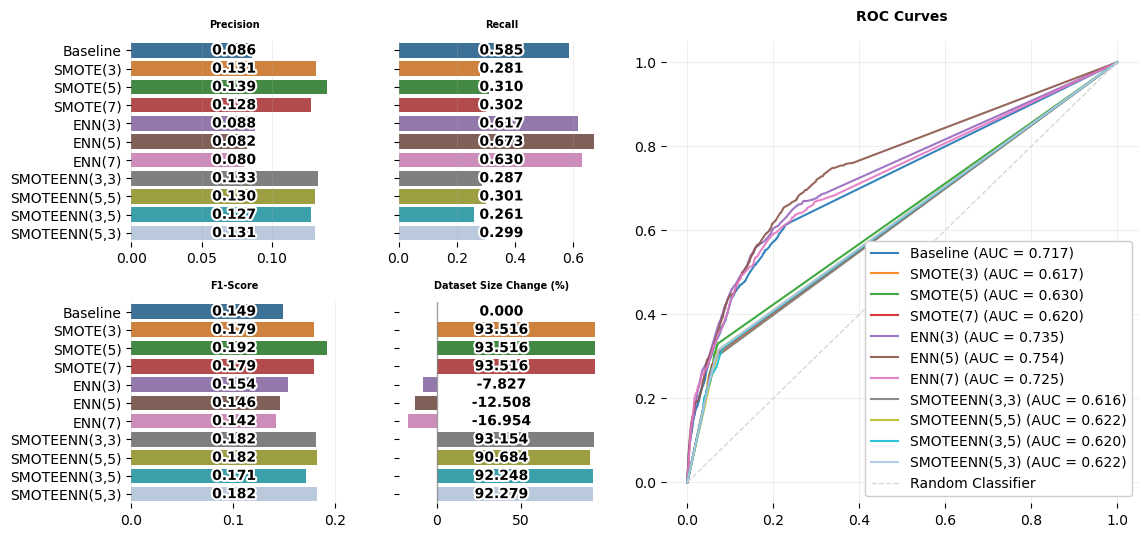

In [43]:
plot_results_with_roc(low_results, './results/low', class_name="Low Ratings", 
                      y_test=y_low_test, 
                      y_probas=low_probas)



In [44]:
# ten_results, ten_models, ten_probas = run_experiment(
#     X_10_train, y_10_train, X_10_test, y_10_test, 
#     strategies=strategies_config
# )

In [45]:
# import joblib
# import json

# created_results_dir = 'results/model'
# created_proba_dir = 'results/proba'
# if not os.path.exists(created_results_dir):
#     os.makedirs(created_results_dir)
# if not os.path.exists(created_proba_dir):
#     os.makedirs(created_proba_dir)

# # to json low_results, low_models, low_probas
# ten_results.to_json('results/ten_results.json', orient='records', indent=4)
# #Salva i modelli in formato pickle
# for strategy, model in ten_models.items():
#     joblib.dump(model, f'results/model/ten_model_{strategy}.pkl')
# # Salva le probabilità in formato pickle
# for strategy, proba in ten_probas.items():
#     with open(f'results/proba/ten_proba_{strategy}.pkl', 'wb') as f:
#         joblib.dump(proba, f)

In [46]:
#load
ten_results, ten_models, ten_probas
ten_results = pd.read_json('results/ten_results.json', orient='records')
ten_models = {}
for strategy in ten_results['strategy'].unique():
    ten_models[strategy] = joblib.load(f'results/model/ten_model_{strategy}.pkl')
ten_probas = {}
for strategy in ten_results['strategy'].unique():
    with open(f'results/proba/ten_proba_{strategy}.pkl', 'rb') as f:
        ten_probas[strategy] = joblib.load(f)


/tmp/ipykernel_60372/884462252.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=results_with_change, y='strategy', x=metric,
/tmp/ipykernel_60372/884462252.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=results_with_change, y='strategy', x=metric,
/tmp/ipykernel_60372/884462252.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=results_with_change, y='strategy', x=metric,
/tmp/ipykernel_60372/884462252.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be r

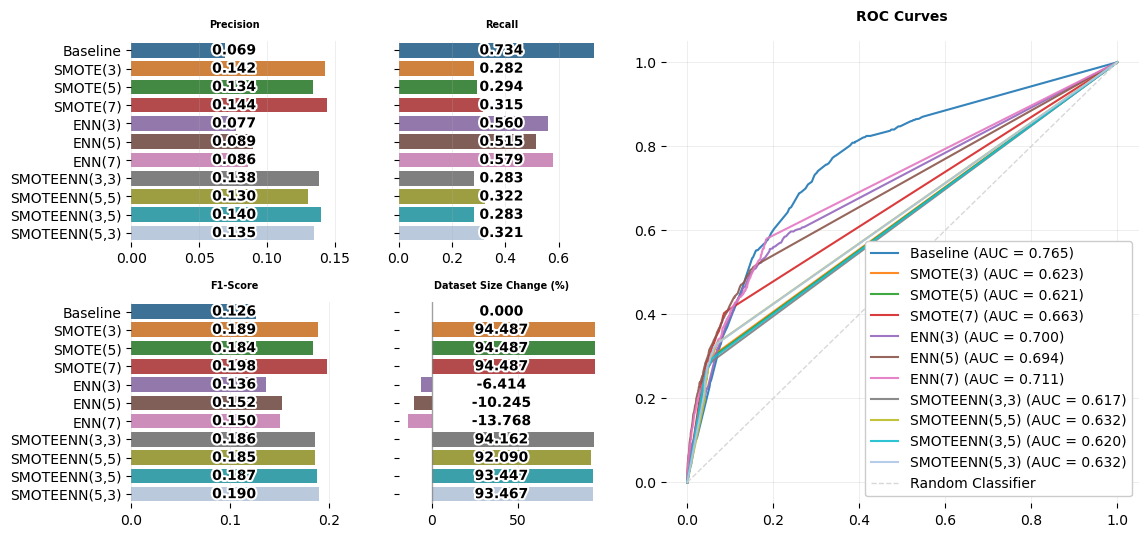

In [47]:
plot_results_with_roc(ten_results, './results/ten', class_name="10", y_test=y_10_test,  y_probas=ten_probas)